In [1]:
#Fix relative paths
from pathlib import Path
import os
import sys

p = Path.cwd().resolve()
repo_root = next(parent for parent in [p, *p.parents] if (parent / "src").exists())
sys.path.insert(0, str(repo_root / "src"))

In [2]:
#imports
import numpy as np
import torch.nn as nn
import torch
import json
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision import transforms
from dataset import load_split
from torch_dataset import ImagePathDataset
from resnet_model import build_resnet18_feature_extractor, extract_features, build_resnet18

PART 1: FEATURE-EXTRACTION

In [3]:
# config
FEATURE_OUT_DIR = "data/features_resnet"
os.makedirs(FEATURE_OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64               
NUM_WORKERS = 4               
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

In [4]:
#load dataset splits
train_paths, test_paths, train_labels, test_labels, meta = load_split(repo_root / "splits")
num_classes = len(meta["label2idx"])
print("Train:", len(train_paths), "Test:", len(test_paths), "Num classes:", num_classes)

Train: 6073 Test: 2604 Num classes: 101


In [5]:
from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=0.15,
    stratify=train_labels,
    random_state=SEED
)

In [6]:
# Transform Data to ImageNet standard
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

test_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [7]:
"""DATALOADERS"""
train_ds = ImagePathDataset(train_paths, train_labels, transform=test_tfms)
test_ds  = ImagePathDataset(test_paths, test_labels, transform=test_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [8]:
"""FROZEN FEATURE EXTRACTOR"""
fe_model = build_resnet18_feature_extractor(pretrained=True, freeze_backbone=True)
fe_model = fe_model.to(DEVICE)

c:\Users\Kwame Boateng\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Kwame Boateng\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
"""EXTRACT FEATURES"""
#Extract features and save
X_train_path = os.path.join(FEATURE_OUT_DIR, "resnet18_X_train.npy")
y_train_path = os.path.join(FEATURE_OUT_DIR, "resnet18_y_train.npy")
X_test_path  = os.path.join(FEATURE_OUT_DIR, "resnet18_X_test.npy")
y_test_path  = os.path.join(FEATURE_OUT_DIR, "resnet18_y_test.npy")

# skip extraction if files exist
if not (os.path.exists(X_train_path) and os.path.exists(X_test_path)):
    X_train, y_train = extract_features(fe_model, train_loader, device=DEVICE, return_labels=True)
    X_test, y_test   = extract_features(fe_model, test_loader,  device=DEVICE, return_labels=True)

    np.save(X_train_path, X_train)
    np.save(y_train_path, y_train)
    np.save(X_test_path, X_test)
    np.save(y_test_path, y_test)
    print("Saved features.")
else:
    X_train, y_train = np.load(X_train_path), np.load(y_train_path)
    X_test, y_test   = np.load(X_test_path),  np.load(y_test_path)
    print("Loaded cached features.")
print("Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

Loaded cached features.
Shapes: (6073, 512) (6073,) (2604, 512) (2604,)


In [10]:
"""NORMALIZE FEATURES"""
from sklearn.preprocessing import StandardScaler, normalize

#L2 normalize rows
X_train_norm = normalize(X_train, norm='l2', axis=1)
X_test_norm  = normalize(X_test,  norm='l2', axis=1)

In [11]:
"""CROSS VALIDATION"""
#train classifier with CV to pick regularization
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
param_grid = {"C": [1e-3, 1e-2, 1e-1, 1, 10, 100]}

clf = LogisticRegression(solver='lbfgs', max_iter=2000, class_weight='balanced',random_state=SEED)
grid = GridSearchCV(clf, param_grid, cv=cv, n_jobs=-1, scoring='accuracy')
grid.fit(X_train_norm, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'C': 100}
Best CV score: 0.9221152398966787


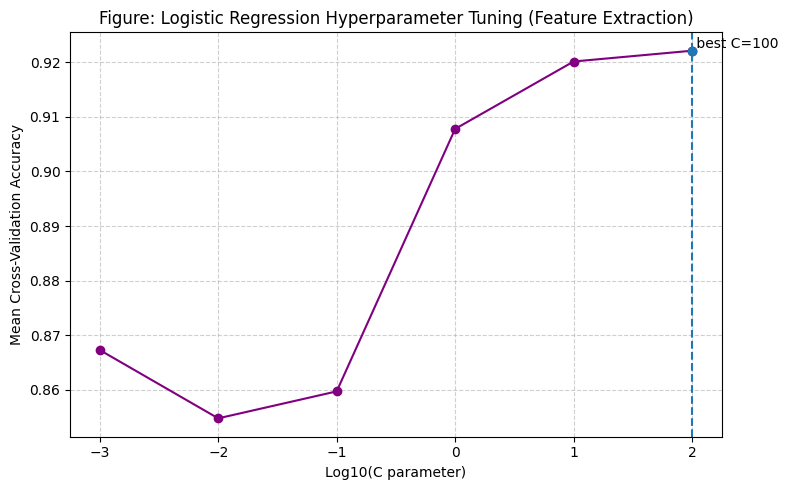

In [12]:
import matplotlib.pyplot as plt
import numpy as np

#Plot
c_values = grid.cv_results_['param_C'].data.astype(float)
mean_scores = grid.cv_results_['mean_test_score']

plt.figure(figsize=(8, 5))
plt.plot(np.log10(c_values), mean_scores, marker='o', color='purple')
plt.title("Figure: Logistic Regression Hyperparameter Tuning (Feature Extraction)")
best_c = grid.best_params_["C"]
best_x = np.log10(best_c)
best_y = grid.best_score_

plt.axvline(best_x, linestyle="--")
plt.scatter([best_x], [best_y], zorder=3)
plt.text(best_x, best_y, f" best C={best_c}", va="bottom", ha="left")
plt.xlabel("Log10(C parameter)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("feature_extraction_cv_curve.png", dpi=300)
plt.show()

In [13]:
"""FIT FINAL MODEL"""
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_norm)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

Test accuracy: 0.9278033794162827
              precision    recall  f1-score   support

           0      0.932     0.939     0.935       131
           1      0.938     0.931     0.935       131
           2      0.983     0.983     0.983        60
           3      1.000     1.000     1.000       239
           4      1.000     1.000     1.000        16
           5      0.996     0.992     0.994       240
           6      0.909     0.769     0.833        13
           7      0.692     0.692     0.692        13
           8      1.000     0.857     0.923        14
           9      0.778     0.875     0.824        16
          10      1.000     0.643     0.783        14
          11      0.833     1.000     0.909        10
          12      0.974     0.974     0.974        38
          13      1.000     0.897     0.945        29
          14      0.611     0.846     0.710        13
          15      1.000     1.000     1.000        26
          16      0.857     0.889     0.873    

In [14]:
"""SAVE RESULTS."""
import json
results = {
    "best_params": grid.best_params_,
    "cv_score": float(grid.best_score_),
    "test_accuracy": float(accuracy_score(y_test, y_pred))
}
with open(os.path.join(FEATURE_OUT_DIR, "resnet18_results.json"), "w") as f:
    json.dump(results, f, indent=2)
np.save(os.path.join(FEATURE_OUT_DIR, "resnet18_y_pred.npy"), y_pred)
print("Saved results.")

Saved results.


PART 2: FINE-TUNNING

In [15]:
train_ds_ft = ImagePathDataset(train_paths, train_labels, transform=train_tfms)
val_ds_ft   = ImagePathDataset(val_paths,   val_labels,   transform=test_tfms)
test_ds_ft  = ImagePathDataset(test_paths,  test_labels,  transform=test_tfms)

train_loader_ft = DataLoader(train_ds_ft, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader_ft   = DataLoader(val_ds_ft,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader_ft  = DataLoader(test_ds_ft,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [16]:
model = build_resnet18(num_classes=num_classes, pretrained=True, freeze_backbone=True).to(DEVICE)
criterion = nn.CrossEntropyLoss()

c:\Users\Kwame Boateng\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Kwame Boateng\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
"""TRAINING-UTILITIES"""
def _to_device_labels(y, device):
    # handles either tensor labels or python ints/lists
    if isinstance(y, torch.Tensor):
        return y.to(device)
    return torch.as_tensor(y, device=device, dtype=torch.long)

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device)
        y = _to_device_labels(y, device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device)
        y = _to_device_labels(y, device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total

In [18]:
"""TRAIN-HEAD Only"""
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(2):
    tr_loss, tr_acc = train_one_epoch(model, train_loader_ft, optimizer, DEVICE)
    te_loss, te_acc = evaluate(model, val_loader_ft, DEVICE)
    print(f"[Head-only] epoch={epoch} train_acc={tr_acc:.3f} val_acc={te_acc:.3f}")

[Head-only] epoch=0 train_acc=0.375 val_acc=0.712
[Head-only] epoch=1 train_acc=0.694 val_acc=0.836


[Layer4+FC] epoch=1 train_acc=0.780 val_acc=0.902
[Layer4+FC] epoch=2 train_acc=0.861 val_acc=0.932
[Layer4+FC] epoch=3 train_acc=0.884 val_acc=0.915
[Layer4+FC] epoch=4 train_acc=0.898 val_acc=0.928
[Layer4+FC] epoch=5 train_acc=0.909 val_acc=0.924
[Layer4+FC] epoch=6 train_acc=0.917 val_acc=0.931
[Layer4+FC] epoch=7 train_acc=0.916 val_acc=0.917
[Layer4+FC] epoch=8 train_acc=0.918 val_acc=0.924
[Layer4+FC] epoch=9 train_acc=0.929 val_acc=0.919
[Layer4+FC] epoch=10 train_acc=0.929 val_acc=0.913
Best val acc: 0.9319429198682766
Saved best checkpoint to: data/models/resnet18_finetuned_best.pt


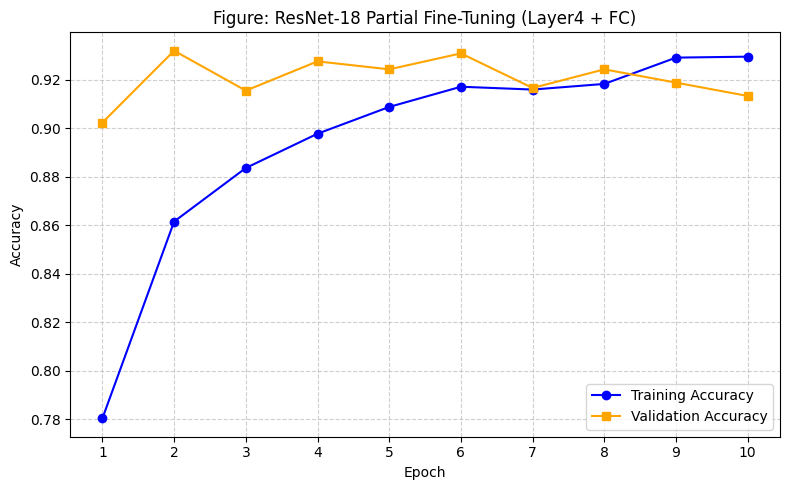

In [19]:
"""UNFREEZE LAYER AND FINE-TUNE"""
import os
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

os.makedirs("data/models", exist_ok=True)

# freeze everything, then unfreeze layer4 + fc
for name, p in model.named_parameters():
    p.requires_grad = name.startswith("layer4.") or name.startswith("fc.")

params = [
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(),     "lr": 1e-3},
]
optimizer = optim.Adam(params, weight_decay=1e-4)

best_acc = -1.0
best_path = "data/models/resnet18_finetuned_best.pt"

#Initialize lists to store history
train_acc_history = []
val_acc_history = []
epochs_list = []

for epoch in range(10):
    tr_loss, tr_acc = train_one_epoch(model, train_loader_ft, optimizer, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader_ft, DEVICE)
    
    # +1 so epochs display as 1-10 instead of 0-9
    current_epoch = epoch + 1
    print(f"[Layer4+FC] epoch={current_epoch} train_acc={tr_acc:.3f} val_acc={val_acc:.3f}")
    
    #Save the accuracy for this epoch
    train_acc_history.append(tr_acc)
    val_acc_history.append(val_acc)
    epochs_list.append(current_epoch)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_path)

print("Best val acc:", best_acc)
print("Saved best checkpoint to:", best_path)

#Automatically generate and save the plot
plt.figure(figsize=(8, 5))
plt.plot(epochs_list, train_acc_history, marker='o', label='Training Accuracy', color='blue')
plt.plot(epochs_list, val_acc_history, marker='s', label='Validation Accuracy', color='orange')

plt.title("Figure: ResNet-18 Partial Fine-Tuning (Layer4 + FC)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs_list)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("resnet_learning_curve.png", dpi=300)
plt.show()

In [20]:
"""Final Fine Tuned Model"""
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
_, final_test_acc = evaluate(model, test_loader_ft, DEVICE)
print("Final test acc (best checkpoint):", final_test_acc)

finetune_results = {
    "setting": "resnet18_finetune_layer4_fc",
    "epochs_head_only": 2,
    "epochs_finetune": 10,
    "lr_head": 1e-3,
    "lr_layer4": 1e-4,
    "weight_decay": 1e-4,
    "best_test_accuracy": float(final_test_acc),
    "checkpoint_path": best_path,
}

out_path = os.path.join(FEATURE_OUT_DIR, "resnet18_finetune_results.json")
with open(out_path, "w") as f:
    json.dump(finetune_results, f, indent=2)

print("Saved fine-tune results to:", out_path)

Final test acc (best checkpoint): 0.9032258064516129
Saved fine-tune results to: data/features_resnet\resnet18_finetune_results.json


In [21]:
from sklearn.metrics import classification_report
import torch
import numpy as np

model.eval()
all_preds_rn = []
all_labels_rn = []

with torch.no_grad():
    for x, y in test_loader_ft:
        x = x.to(DEVICE)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        
        all_preds_rn.append(preds.cpu().numpy())
        all_labels_rn.append(y.numpy())

all_preds_rn = np.concatenate(all_preds_rn)
all_labels_rn = np.concatenate(all_labels_rn)

print("--- RESNET-18 (FINE-TUNED) OVERALL METRICS ---")
print(classification_report(all_labels_rn, all_preds_rn, digits=3))

--- RESNET-18 (FINE-TUNED) OVERALL METRICS ---
              precision    recall  f1-score   support

           0      0.942     0.870     0.905       131
           1      0.879     0.947     0.912       131
           2      0.983     0.983     0.983        60
           3      0.988     1.000     0.994       239
           4      1.000     1.000     1.000        16
           5      0.956     1.000     0.978       240
           6      0.833     0.769     0.800        13
           7      0.480     0.923     0.632        13
           8      1.000     0.714     0.833        14
           9      1.000     0.625     0.769        16
          10      0.700     0.500     0.583        14
          11      0.833     1.000     0.909        10
          12      0.950     1.000     0.974        38
          13      0.960     0.828     0.889        29
          14      0.526     0.769     0.625        13
          15      1.000     1.000     1.000        26
          16      0.885     0.852 